# Adaptive Evidential Fusion (ADEF) - CLARA Hybrid Model
## Multimodal Sentiment Analysis with Evidential Deep Learning (EDL) & Parameter-Efficient Vision-Language Fusion
**Author:** Erlangga Dewa Sakti  
**Specification:** *Adaptive Evidential Fusion for Uncertainty-Aware Cross-Modal Fusion in Multimodal Sentiment Analysis*

---
### 1. Setup & Environment Initialization


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import random
import sys
import warnings
import json
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from transformers import AutoTokenizer, DebertaV2Model, CLIPVisionModel
from peft import get_peft_model, LoraConfig, TaskType

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")

# ============================================================
# REPRODUCIBILITY & SEEDING
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("[INFO] Imports loaded & global seed set to 42.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")


C:\Users\Residensi ADW\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Imports loaded & global seed set to 42.
PyTorch version: 2.7.1+cu118
CUDA available: True
GPU Device: NVIDIA GeForce RTX 3060


---
### 2. Configuration (`CFG` Class)
Centralized configuration management for dataset parameters, CLARA backbones (CLIP-ViT + DeBERTa-v3 with LoRA), ADEF hyperparameters, and training settings.


In [2]:
# ============================================================
# CONFIGURATION CLASS (CLARA-ENHANCED ADEF)
# ============================================================

class CFG:
    # --- Seed & System Setup ---
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS = 0  # 0 for safe multi-processing on Windows

    # --- Dataset & File Paths ---
    DATASET_NAME = "MVSA-Single"
    ROOT_DIR = "D:/MVSA_SINGLE" if os.path.exists("D:/MVSA_SINGLE") else "./data/MVSA_Single"
    DATA_DIR = os.path.join(ROOT_DIR, "data") if os.path.exists(os.path.join(ROOT_DIR, "data")) else "./data/MVSA_Single/images"
    LABEL_PATH = os.path.join(ROOT_DIR, "labelResultAllFinal.txt") if os.path.exists(os.path.join(ROOT_DIR, "labelResultAllFinal.txt")) else "./data/MVSA_Single/data_label.csv"
    OUTPUT_DIR = "./output_clara"

    # --- Unimodal Feature Backbones (CLARA Specification) ---
    TEXT_BACKBONE = "microsoft/deberta-v3-base"
    VISION_BACKBONE = "openai/clip-vit-base-patch16"

    # --- LoRA Adapter Hyperparameters (CLARA Specification) ---
    LORA_RANK = 8
    LORA_ALPHA = 16
    LORA_DROPOUT = 0.05

    # --- Architecture Dimensions ---
    FEATURE_DIM = 512
    NUM_HEADS = 8
    NUM_COATT_LAYERS = 2
    NUM_CLASSES = 3                       # Sentimen: 0=Negative, 1=Neutral, 2=Positive

    # --- Image & Text Preprocessing Settings ---
    IMAGE_SIZE = 224
    MAX_LEN = 128
    NORM_MEAN = [0.485, 0.456, 0.406]
    NORM_STD = [0.229, 0.224, 0.225]

    # --- ADEF Threshold Hyperparameter ---
    TAU_THRESHOLD = 0.03                   # Ambang batas Conflict Mass (tau)

    # --- Training Hyperparameters ---
    BATCH_SIZE = 32
    EPOCHS = 20
    LR_BACKBONE = 2e-5                    # Fine-tuning rate untuk LoRA weights
    LR_HEAD = 1e-4                        # Learning rate untuk Co-Attention, ENN, ADEF Head
    WEIGHT_DECAY = 0.01
    KL_ANNEALING_EPOCHS = 10              # Epoch annealing untuk EDL KL Divergence Loss

    # --- Visualization & Logging ---
    SAVE_PLOTS = True
    PLOT_FORMAT = "png"

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
print(f"[INFO] CFG loaded. Operating on Device: {CFG.DEVICE}")
print(f"Dataset root: {CFG.ROOT_DIR}")
print(f"Output directory: {CFG.OUTPUT_DIR}")


[INFO] CFG loaded. Operating on Device: cuda
Dataset root: D:/MVSA_SINGLE
Output directory: ./output_clara


---
### 3. Dataset & DataLoader
PyTorch `MultimodalDataset` handling paired image-text inputs, text tokenization with DeBERTa-v3, image preprocessing for CLIP, stratified splits, and Class Weights computation.


In [3]:
# ============================================================
# DATA PREPARATION & PYTORCH DATASET
# ============================================================

def load_and_preprocess_dataframe():
    if CFG.LABEL_PATH.endswith(".txt"):
        df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=",")
        df.columns = ["id", "text_label", "image_label", "final_label"]

        # Filter conflicting text/image sentiment pairs (e.g. positive text + negative image)
        def is_valid(row):
            if row["text_label"] == "positive" and row["image_label"] == "negative":
                return False
            if row["text_label"] == "negative" and row["image_label"] == "positive":
                return False
            return True

        df = df[df.apply(is_valid, axis=1)].reset_index(drop=True)
    else:
        df = pd.read_csv(CFG.LABEL_PATH)

    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    if "label" not in df.columns and "final_label" in df.columns:
        df["label"] = df["final_label"].map(label_map)

    # Load text content per ID if reading MVSA text files
    def load_text(sample_id):
        path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")
        if not os.path.exists(path):
            path_alt = os.path.join(CFG.ROOT_DIR, "data", f"{sample_id}.txt")
            if os.path.exists(path_alt):
                path = path_alt
            else:
                return ""
        encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]
        for enc in encodings:
            try:
                with open(path, "r", encoding=enc) as f:
                    text = f.read().strip()
                    if text:
                        return text
            except Exception:
                continue
        return ""

    if "text" not in df.columns or df["text"].isnull().all():
        df["text"] = df["id"].apply(load_text)

    # Build image paths
    def get_image_path(sample_id):
        img_path = os.path.join(CFG.DATA_DIR, f"{sample_id}.jpg")
        if not os.path.exists(img_path):
            img_path_alt = os.path.join(CFG.ROOT_DIR, "data", f"{sample_id}.jpg")
            if os.path.exists(img_path_alt):
                return img_path_alt
        return img_path

    df["image_path"] = df["id"].apply(get_image_path)
    return df

df_full = load_and_preprocess_dataframe()
print(f"Total samples after filtering: {len(df_full)}")

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, transform, max_len=128):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row["text"]) if pd.notna(row["text"]) and str(row["text"]).strip() != "" else "empty"
        image_path = row["image_path"]
        label = int(row["label"])

        # Tokenize text with DeBERTa-v3
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # Load & transform image for CLIP
        try:
            image = Image.open(image_path).convert("RGB")
            image = self.transform(image)
        except Exception:
            image = torch.zeros(3, CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": torch.tensor(label, dtype=torch.long)
        }

# Preprocessing transforms & DeBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained(CFG.TEXT_BACKBONE)
image_transform = transforms.Compose([
    transforms.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=CFG.NORM_MEAN, std=CFG.NORM_STD)
])

# Stratified 70% Train, 15% Val, 15% Test split
train_df, temp_df = train_test_split(df_full, test_size=0.30, stratify=df_full["label"], random_state=CFG.SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=CFG.SEED)

train_dataset = MultimodalDataset(train_df, tokenizer, image_transform, max_len=CFG.MAX_LEN)
val_dataset = MultimodalDataset(val_df, tokenizer, image_transform, max_len=CFG.MAX_LEN)
test_dataset = MultimodalDataset(test_df, tokenizer, image_transform, max_len=CFG.MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=CFG.NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)

# Calculate Class Weights to solve Neutral Class Imbalance
class_counts = train_df["label"].value_counts().sort_index().values
total_samples = len(train_df)
class_weights = total_samples / (CFG.NUM_CLASSES * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(CFG.DEVICE)

print(f"[INFO] DataLoaders Ready: Train ({len(train_df)}), Val ({len(val_df)}), Test ({len(test_df)})")
print(f"Class Counts (Train): Negative={class_counts[0]}, Neutral={class_counts[1]}, Positive={class_counts[2]}")
print(f"Class Weights (Loss): {class_weights.cpu().numpy()}")


Total samples after filtering: 4511


[INFO] DataLoaders Ready: Train (3157), Val (677), Test (677)
Class Counts (Train): Negative=950, Neutral=329, Positive=1878
Class Weights (Loss): [1.1077193 3.1985815 0.5603479]


---
### 4. Model Building Blocks
PyTorch implementations of `MultiHeadCoAttentionLayer` (CLARA 2-layer co-attention), `EvidentialLayer` (ENN), and `ADEFModule` matching thesis specifications.


In [4]:
# ============================================================
# ARCHITECTURE BUILDING BLOCKS
# ============================================================

class MultiHeadCoAttentionLayer(nn.Module):
    """
    CLARA-style 2-Layer Bidirectional Multi-Head Co-Attention Layer:
    - Text queries Vision (MultiheadAttention)
    - Vision queries Text (MultiheadAttention)
    - Residual Connection + Layer Normalization
    - GELU Feed-Forward Network (FFN)
    """
    def __init__(self, hidden_dim=512, num_heads=8, dropout=0.1):
        super(MultiHeadCoAttentionLayer, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads

        # Text queries Vision
        self.text_to_vision_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )

        # Vision queries Text
        self.vision_to_text_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )

        self.text_norm = nn.LayerNorm(hidden_dim)
        self.vision_norm = nn.LayerNorm(hidden_dim)

        self.text_ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )
        self.vision_ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

        self.text_ffn_norm = nn.LayerNorm(hidden_dim)
        self.vision_ffn_norm = nn.LayerNorm(hidden_dim)

    def forward(self, text_features, vision_features):
        # text_features: (B, L, D), vision_features: (B, N, D)
        text_attn_out, _ = self.text_to_vision_attn(query=text_features, key=vision_features, value=vision_features)
        text_features = self.text_norm(text_features + text_attn_out)

        vision_attn_out, _ = self.vision_to_text_attn(query=vision_features, key=text_features, value=text_features)
        vision_features = self.vision_norm(vision_features + vision_attn_out)

        text_out = self.text_ffn_norm(text_features + self.text_ffn(text_features))
        vision_out = self.vision_ffn_norm(vision_features + self.vision_ffn(vision_features))

        return text_out, vision_out


class EvidentialLayer(nn.Module):
    """
    Evidential Neural Network (ENN) Layer:
    - Evidence: e_k,i = ReLU(W_k * h_k + b_k) >= 0
    - Dirichlet Parameters: alpha_k,i = e_k,i + 1
    - Dirichlet Strength: S_k = sum(alpha_k,i)
    - Belief Mass: b_k,i = e_k,i / S_k
    - Uncertainty Mass: u_k = M / S_k
    """
    def __init__(self, in_dim=512, num_classes=3):
        super(EvidentialLayer, self).__init__()
        self.fc = nn.Linear(in_dim, num_classes)
        self.num_classes = num_classes

    def forward(self, h):
        logits = self.fc(h)
        evidence = F.relu(logits)                        # e_k,i >= 0
        alpha = evidence + 1.0                           # alpha_k,i = e_k,i + 1
        S = torch.sum(alpha, dim=-1, keepdim=True)       # S_k = sum(alpha_k,i)
        b = evidence / S                                 # b_k,i = e_k,i / S_k
        u = self.num_classes / S                         # u_k = M / S_k
        return {
            "logits": logits,
            "evidence": evidence,
            "alpha": alpha,
            "b": b,
            "u": u,
            "S": S
        }


class ADEFModule(nn.Module):
    """
    Adaptive Evidential Fusion (ADEF) Module:
    1. Conflict Mass K_tv = sum_{i != j} b_t,i * b_v,j
    2. Dynamic Branching:
       - Route A (K_tv <= tau): Standard Dempster-Shafer Combination (T (+) V) (+) C
       - Route B (K_tv > tau): Adaptive Conflict-Aware Fusion:
         b_fusion = (1 - K_tv) * (b_t + b_v)/2 + K_tv * b_c
         u_fusion = 1 - sum(b_fusion)
    3. Final Prediction Probability: p_i = b_fusion,i + u_fusion / M
    """
    def __init__(self, tau=0.03, num_classes=3):
        super(ADEFModule, self).__init__()
        self.tau = tau
        self.num_classes = num_classes

    def forward(self, b_t, u_t, b_v, u_v, b_c, u_c):
        # 1. Conflict Mass K_tv calculation: K_tv = sum_{i != j} b_t,i * b_v,j
        b_t_sum = b_t.sum(dim=-1, keepdim=True)         # (B, 1)
        b_v_sum = b_v.sum(dim=-1, keepdim=True)         # (B, 1)
        K_tv = b_t_sum * b_v_sum - torch.sum(b_t * b_v, dim=-1, keepdim=True) # (B, 1)
        K_tv = torch.clamp(K_tv, min=0.0, max=0.9999)

        # ROUTE A: Standard Dempster-Shafer Combination (K_tv <= tau)
        denom_tv = torch.clamp(1.0 - K_tv, min=1e-8)
        b_tv = (b_t * b_v + b_t * u_v + b_v * u_t) / denom_tv  # (B, M)
        u_tv = (u_t * u_v) / denom_tv                          # (B, 1)

        b_tv_sum = b_tv.sum(dim=-1, keepdim=True)
        b_c_sum = b_c.sum(dim=-1, keepdim=True)
        K_tvc = b_tv_sum * b_c_sum - torch.sum(b_tv * b_c, dim=-1, keepdim=True)
        denom_tvc = torch.clamp(1.0 - K_tvc, min=1e-8)

        b_routeA = (b_tv * b_c + b_tv * u_c + b_c * u_tv) / denom_tvc # (B, M)
        u_routeA = (u_tv * u_c) / denom_tvc                           # (B, 1)

        # ROUTE B: Adaptive Conflict-Aware Fusion (K_tv > tau)
        b_routeB = (1.0 - K_tv) * ((b_t + b_v) / 2.0) + K_tv * b_c   # (B, M)
        u_routeB = 1.0 - torch.sum(b_routeB, dim=-1, keepdim=True)   # (B, 1)
        u_routeB = torch.clamp(u_routeB, min=0.0)

        # DYNAMIC SELECTION (VECTORIZED BATCH BRANCHING)
        route_a_mask = (K_tv <= self.tau)                             # (B, 1)
        b_fusion = torch.where(route_a_mask, b_routeA, b_routeB)     # (B, M)
        u_fusion = torch.where(route_a_mask, u_routeA, u_routeB)     # (B, 1)

        p = b_fusion + (u_fusion / self.num_classes)                  # (B, M)

        return p, b_fusion, u_fusion, K_tv

print("[INFO] Architecture Building Blocks (`MultiHeadCoAttentionLayer`, `EvidentialLayer`, `ADEFModule`) defined.")


[INFO] Architecture Building Blocks (`MultiHeadCoAttentionLayer`, `EvidentialLayer`, `ADEFModule`) defined.


---
### 5. Full Model Assembly (`ADEFCLARAModel`)
Complete end-to-end architecture fusing DeBERTa-v3 + LoRA text features, CLIP-ViT + LoRA visual features, 2-layer Multi-Head Co-Attention, and Adaptive Evidential Fusion. Accessing `.base_model` on PEFT models prevents PEFT argument forwarding collisions.


In [5]:
# ============================================================
# FULL ADEF-CLARA MODEL ASSEMBLY
# ============================================================

class ADEFCLARAModel(nn.Module):
    def __init__(self, cfg):
        super(ADEFCLARAModel, self).__init__()
        self.cfg = cfg

        # 1. Text Encoder (DeBERTa-v3 with LoRA)
        self.text_encoder = DebertaV2Model.from_pretrained(cfg.TEXT_BACKBONE)
        text_lora_config = LoraConfig(
            r=cfg.LORA_RANK,
            lora_alpha=cfg.LORA_ALPHA,
            target_modules=["query_proj", "value_proj"],
            lora_dropout=cfg.LORA_DROPOUT,
            bias="none"
        )
        self.text_encoder = get_peft_model(self.text_encoder, text_lora_config).float()
        self.text_proj = nn.Linear(self.text_encoder.config.hidden_size, cfg.FEATURE_DIM)

        # 2. Visual Encoder (CLIP ViT with LoRA)
        self.visual_encoder = CLIPVisionModel.from_pretrained(cfg.VISION_BACKBONE)
        vision_lora_config = LoraConfig(
            r=cfg.LORA_RANK,
            lora_alpha=cfg.LORA_ALPHA,
            target_modules=["q_proj", "v_proj"],
            lora_dropout=cfg.LORA_DROPOUT,
            bias="none"
        )
        self.visual_encoder = get_peft_model(self.visual_encoder, vision_lora_config).float()
        self.visual_proj = nn.Linear(self.visual_encoder.config.hidden_size, cfg.FEATURE_DIM)

        # 3. 2-Layer Bidirectional Multi-Head Co-Attention
        self.co_attention_layers = nn.ModuleList([
            MultiHeadCoAttentionLayer(hidden_dim=cfg.FEATURE_DIM, num_heads=cfg.NUM_HEADS, dropout=0.1)
            for _ in range(cfg.NUM_COATT_LAYERS)
        ])

        # 4. Evidential Neural Networks (ENN)
        self.enn_text = EvidentialLayer(in_dim=cfg.FEATURE_DIM, num_classes=cfg.NUM_CLASSES)
        self.enn_visual = EvidentialLayer(in_dim=cfg.FEATURE_DIM, num_classes=cfg.NUM_CLASSES)
        self.enn_coatt = EvidentialLayer(in_dim=cfg.FEATURE_DIM, num_classes=cfg.NUM_CLASSES)

        # 5. Adaptive Evidential Fusion Module
        self.adef = ADEFModule(tau=cfg.TAU_THRESHOLD, num_classes=cfg.NUM_CLASSES)

    def forward(self, input_ids, attention_mask, image):
        # Text encoding & projection (access base_model to prevent PEFT arg collision)
        text_out = self.text_encoder.base_model(input_ids=input_ids, attention_mask=attention_mask)
        h_t_seq = self.text_proj(text_out.last_hidden_state.to(torch.float32))     # (B, L, D)

        # Vision encoding & projection (access base_model to prevent PEFT arg collision)
        vision_out = self.visual_encoder.base_model(pixel_values=image)
        h_v_spatial = self.visual_proj(vision_out.last_hidden_state.to(torch.float32)) # (B, N, D)

        # Co-Attention stack
        h_t_att, h_v_att = h_t_seq, h_v_spatial
        for layer in self.co_attention_layers:
            h_t_att, h_v_att = layer(h_t_att, h_v_att)

        # Mean pooling
        h_t = h_t_att.mean(dim=1)                                # (B, D)
        h_v = h_v_att.mean(dim=1)                                # (B, D)
        h_c = (h_t + h_v) / 2.0                                  # (B, D)

        # ENN Evidence calculation
        enn_t = self.enn_text(h_t)
        enn_v = self.enn_visual(h_v)
        enn_c = self.enn_coatt(h_c)

        # ADEF Fusion
        p, b_fusion, u_fusion, K_tv = self.adef(
            enn_t["b"], enn_t["u"],
            enn_v["b"], enn_v["u"],
            enn_c["b"], enn_c["u"]
        )

        return {
            "probs": p,
            "b_fusion": b_fusion,
            "u_fusion": u_fusion,
            "K_tv": K_tv,
            "enn_text": enn_t,
            "enn_visual": enn_v,
            "enn_coatt": enn_c
        }

model = ADEFCLARAModel(CFG).to(CFG.DEVICE)
print(f"[INFO] `ADEFCLARAModel` assembled successfully on device {CFG.DEVICE}.")


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 11945.97it/s]
[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not o

[INFO] `ADEFCLARAModel` assembled successfully on device cuda.


---
### 6. Evidential Loss Function & Optimizer Setup
Implementation of `WeightedEDLLoss` combining Dirichlet expected MSE, KL Divergence regularization, and Class Weights to counter class imbalance.


In [6]:
# ============================================================
# WEIGHTED EVIDENTIAL DEEP LEARNING (EDL) LOSS & OPTIMIZER
# ============================================================

class WeightedEDLLoss(nn.Module):
    """
    Class-Weighted Evidential Deep Learning (EDL) Loss:
    L_EDL = L_MSE + lambda_t * L_KL
    Weighted by class_weights to handle extreme class imbalance (especially Neutral class).
    """
    def __init__(self, num_classes=3, class_weights=None):
        super(WeightedEDLLoss, self).__init__()
        self.num_classes = num_classes
        self.class_weights = class_weights

    def kl_divergence(self, alpha, num_classes):
        beta = torch.ones((1, num_classes), dtype=torch.float32, device=alpha.device)
        S_alpha = torch.sum(alpha, dim=-1, keepdim=True)
        S_beta = torch.sum(beta, dim=-1, keepdim=True)

        lnB = torch.lgamma(S_alpha) - torch.sum(torch.lgamma(alpha), dim=-1, keepdim=True)
        lnB_prior = torch.sum(torch.lgamma(beta), dim=-1, keepdim=True) - torch.lgamma(S_beta)

        dgAlpha = torch.digamma(alpha)
        dgSAlpha = torch.digamma(S_alpha)

        kl = torch.sum((alpha - beta) * (dgAlpha - dgSAlpha), dim=-1, keepdim=True) + lnB + lnB_prior
        return kl

    def forward(self, alpha, y_onehot, epoch, annealing_epochs):
        S = torch.sum(alpha, dim=-1, keepdim=True)
        p_hat = alpha / S

        err = y_onehot - p_hat
        var = (p_hat * (1.0 - p_hat)) / (S + 1.0)
        l_mse = torch.sum(err ** 2 + var, dim=-1, keepdim=True)

        alpha_tilde = y_onehot + (1.0 - y_onehot) * alpha
        kl_reg = self.kl_divergence(alpha_tilde, self.num_classes)

        annealing_coef = min(1.0, float(epoch) / float(annealing_epochs))
        sample_loss = l_mse + annealing_coef * kl_reg

        if self.class_weights is not None:
            # Apply class weighting based on ground-truth target
            weights = torch.sum(y_onehot * self.class_weights.unsqueeze(0), dim=-1, keepdim=True)
            sample_loss = sample_loss * weights

        return torch.mean(sample_loss)

edl_criterion = WeightedEDLLoss(num_classes=CFG.NUM_CLASSES, class_weights=class_weights)

# Differential Learning Rates Setup (LoRA Backbones vs Heads)
backbone_params = [p for p in model.text_encoder.parameters() if p.requires_grad] +                   [p for p in model.visual_encoder.parameters() if p.requires_grad]

head_params = (
    list(model.text_proj.parameters()) +
    list(model.visual_proj.parameters()) +
    list(model.co_attention_layers.parameters()) +
    list(model.enn_text.parameters()) +
    list(model.enn_visual.parameters()) +
    list(model.enn_coatt.parameters()) +
    list(model.adef.parameters())
)

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": CFG.LR_BACKBONE},
    {"params": head_params, "lr": CFG.LR_HEAD}
], weight_decay=CFG.WEIGHT_DECAY)

print(f"[INFO] `WeightedEDLLoss` and AdamW Optimizer initialized.")
print(f"Trainable Backbone Params: {sum(p.numel() for p in backbone_params)}")
print(f"Trainable Head Params: {sum(p.numel() for p in head_params)}")


[INFO] `WeightedEDLLoss` and AdamW Optimizer initialized.
Trainable Backbone Params: 589824
Trainable Head Params: 13401609


---
### 7. Training & Validation Loop
Full training pipeline tracking loss curves, KL annealing, validation Macro F1 score, and saving the best checkpoint.


In [7]:
# ============================================================
# TRAINING & VALIDATION PIPELINE (WITH AUTOMATIC MIXED PRECISION)
# ============================================================

def train_epoch(model, dataloader, criterion, optimizer, scaler, epoch, cfg):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{cfg.EPOCHS} [Train]")
    for batch in pbar:
        input_ids = batch["input_ids"].to(cfg.DEVICE)
        attention_mask = batch["attention_mask"].to(cfg.DEVICE)
        images = batch["image"].to(cfg.DEVICE)
        labels = batch["label"].to(cfg.DEVICE)

        optimizer.zero_grad()

        # Automatic Mixed Precision (AMP Autocast)
        with torch.cuda.amp.autocast(enabled=(cfg.DEVICE == "cuda")):
            out = model(input_ids, attention_mask, images)
            y_onehot = F.one_hot(labels, num_classes=cfg.NUM_CLASSES).float()

            alpha_fused = out["b_fusion"] * (cfg.NUM_CLASSES / torch.clamp(out["u_fusion"], min=1e-6)) + 1.0
            loss_fused = criterion(alpha_fused, y_onehot, epoch, cfg.KL_ANNEALING_EPOCHS)
            loss_t = criterion(out["enn_text"]["alpha"], y_onehot, epoch, cfg.KL_ANNEALING_EPOCHS)
            loss_v = criterion(out["enn_visual"]["alpha"], y_onehot, epoch, cfg.KL_ANNEALING_EPOCHS)
            loss_c = criterion(out["enn_coatt"]["alpha"], y_onehot, epoch, cfg.KL_ANNEALING_EPOCHS)

            loss = loss_fused + 0.2 * (loss_t + loss_v + loss_c)

        # GradScaler for FP16 backward & optimizer step
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = torch.argmax(out["probs"], dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_loss = total_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


def evaluate(model, dataloader, criterion, epoch, cfg):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(cfg.DEVICE)
            attention_mask = batch["attention_mask"].to(cfg.DEVICE)
            images = batch["image"].to(cfg.DEVICE)
            labels = batch["label"].to(cfg.DEVICE)

            with torch.cuda.amp.autocast(enabled=(cfg.DEVICE == "cuda")):
                out = model(input_ids, attention_mask, images)
                y_onehot = F.one_hot(labels, num_classes=cfg.NUM_CLASSES).float()

                alpha_fused = out["b_fusion"] * (cfg.NUM_CLASSES / torch.clamp(out["u_fusion"], min=1e-6)) + 1.0
                loss = criterion(alpha_fused, y_onehot, epoch, cfg.KL_ANNEALING_EPOCHS)

            total_loss += loss.item()
            preds = torch.argmax(out["probs"], dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    val_loss = total_loss / len(dataloader)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average="macro")
    return val_loss, val_acc, val_f1

# Execute Training Loop with GradScaler & AMP
history = {
    "train_loss": [], "train_acc": [], "train_f1": [],
    "val_loss": [], "val_acc": [], "val_f1": []
}

best_val_f1 = 0.0
best_model_path = os.path.join(CFG.OUTPUT_DIR, "best_adef_model.pt")
scaler = torch.cuda.amp.GradScaler(enabled=(CFG.DEVICE == "cuda"))

for epoch in range(CFG.EPOCHS):
    tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, edl_criterion, optimizer, scaler, epoch, CFG)
    vl_loss, vl_acc, vl_f1 = evaluate(model, val_loader, edl_criterion, epoch, CFG)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["train_f1"].append(tr_f1)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(vl_f1)

    print(f"Epoch {epoch+1:02d}/{CFG.EPOCHS:02d} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} F1: {tr_f1:.4f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} F1: {vl_f1:.4f}")

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> Best Model Saved! Val Macro F1: {best_val_f1:.4f}")

print("[INFO] AMP Training complete.")


Epoch 1/20 [Train]: 100%|██████████| 99/99 [01:17<00:00,  1.28it/s, loss=0.9101]


Epoch 01/20 | Train Loss: 1.1998 Acc: 0.4808 F1: 0.3830 | Val Loss: 0.6357 Acc: 0.5170 F1: 0.4749
  --> Best Model Saved! Val Macro F1: 0.4749


Epoch 2/20 [Train]: 100%|██████████| 99/99 [01:11<00:00,  1.39it/s, loss=0.8787]


Epoch 02/20 | Train Loss: 1.1584 Acc: 0.6025 F1: 0.5359 | Val Loss: 0.7242 Acc: 0.5258 F1: 0.5018
  --> Best Model Saved! Val Macro F1: 0.5018


Epoch 3/20 [Train]: 100%|██████████| 99/99 [01:11<00:00,  1.39it/s, loss=0.8715]


...

Epoch 18/20 | Train Loss: 0.6184 Acc: 0.8514 F1: 0.8199 | Val Loss: 1.6284 Acc: 0.6854 F1: 0.5955


Epoch 19/20 [Train]: 100%|██████████| 99/99 [01:11<00:00,  1.39it/s, loss=0.1578]


Epoch 19/20 | Train Loss: 0.6385 Acc: 0.8438 F1: 0.8109 | Val Loss: 1.7244 Acc: 0.6942 F1: 0.6010


Epoch 20/20 [Train]: 100%|██████████| 99/99 [01:11<00:00,  1.39it/s, loss=0.8407]


Epoch 20/20 | Train Loss: 0.6216 Acc: 0.8578 F1: 0.8292 | Val Loss: 1.8049 Acc: 0.6809 F1: 0.6019
[INFO] AMP Training complete.


---
### 8. Post-Hoc Neutral Logit Calibration & Test Set Execution
Post-hoc grid search calibration for Neutral class logit offset followed by test set evaluation.


In [8]:
# ============================================================
# POST-HOC NEUTRAL LOGIT CALIBRATION & TEST EVALUATION
# ============================================================

if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=CFG.DEVICE))
    print(f"[INFO] Best model weights loaded from {best_model_path}")

model.eval()

# Gather Validation Probabilities & Ground Truth for Calibration
val_probs_raw, val_labels_arr = [], []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(CFG.DEVICE)
        attention_mask = batch["attention_mask"].to(CFG.DEVICE)
        images = batch["image"].to(CFG.DEVICE)
        labels = batch["label"].to(CFG.DEVICE)

        with torch.cuda.amp.autocast(enabled=(CFG.DEVICE == 'cuda')):
            out = model(input_ids, attention_mask, images)
        val_probs_raw.extend(out["probs"].cpu().numpy())
        val_labels_arr.extend(labels.cpu().numpy())

val_probs_raw = np.array(val_probs_raw)
val_labels_arr = np.array(val_labels_arr)

# Grid Search on Validation Set for Neutral Logit Offset (CLARA Calibration)
best_bias = 0.0
best_calib_f1 = f1_score(val_labels_arr, np.argmax(val_probs_raw, axis=1), average="macro")

for bias in np.linspace(-0.5, 1.5, 41):
    calib_probs = val_probs_raw.copy()
    calib_probs[:, 1] += bias  # Adjust neutral class probability
    preds = np.argmax(calib_probs, axis=1)
    f1 = f1_score(val_labels_arr, preds, average="macro")
    if f1 > best_calib_f1:
        best_calib_f1 = f1
        best_bias = bias

print(f"[INFO] Neutral Logit Calibration Complete: Best Neutral Bias = {best_bias:+.4f} (Val Macro F1: {best_calib_f1:.4f})")

# Final Test Set Execution
test_preds, test_labels, test_probs, test_u_fusion, test_K_tv, test_b_fusion = [], [], [], [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing Model"):
        input_ids = batch["input_ids"].to(CFG.DEVICE)
        attention_mask = batch["attention_mask"].to(CFG.DEVICE)
        images = batch["image"].to(CFG.DEVICE)
        labels = batch["label"].to(CFG.DEVICE)

        with torch.cuda.amp.autocast(enabled=(CFG.DEVICE == 'cuda')):
            out = model(input_ids, attention_mask, images)
        probs = out["probs"].cpu().numpy()
        probs[:, 1] += best_bias  # Apply calibrated neutral bias
        preds = np.argmax(probs, axis=-1)

        test_preds.extend(preds)
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs)
        test_u_fusion.extend(out["u_fusion"].squeeze(-1).cpu().numpy())
        test_K_tv.extend(out["K_tv"].squeeze(-1).cpu().numpy())
        test_b_fusion.extend(out["b_fusion"].cpu().numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)
test_u_fusion = np.array(test_u_fusion)
test_K_tv = np.array(test_K_tv)
test_b_fusion = np.array(test_b_fusion)

test_acc = accuracy_score(test_labels, test_preds)
test_f1_macro = f1_score(test_labels, test_preds, average="macro")
test_precision_macro = precision_score(test_labels, test_preds, average="macro")
test_recall_macro = recall_score(test_labels, test_preds, average="macro")

print("="*60)
print("FINAL TEST PERFORMANCE SUMMARY (ADEF-CLARA HYBRID):")
print("="*60)
print(f"Test Accuracy:          {test_acc * 100:.2f}%")
print(f"Test Macro Precision:   {test_precision_macro * 100:.2f}%")
print(f"Test Macro Recall:      {test_recall_macro * 100:.2f}%")
print(f"Test Macro F1-Score:    {test_f1_macro * 100:.2f}%")
print("="*60)

target_names = ["Negative", "Neutral", "Positive"]
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))


[INFO] Best model weights loaded from ./output_clara\best_adef_model.pt
[INFO] Neutral Logit Calibration Complete: Best Neutral Bias = +0.0000 (Val Macro F1: 0.6037)


Testing Model: 100%|██████████| 22/22 [00:09<00:00,  2.30it/s]

FINAL TEST PERFORMANCE SUMMARY (ADEF-CLARA HYBRID):
Test Accuracy:          71.05%
Test Macro Precision:   64.84%
Test Macro Recall:      61.86%
Test Macro F1-Score:    62.90%
              precision    recall  f1-score   support

    Negative     0.6062    0.6716    0.6372       204
     Neutral     0.5490    0.4000    0.4628        70
    Positive     0.7900    0.7841    0.7870       403

    accuracy                         0.7105       677
   macro avg     0.6484    0.6186    0.6290       677
weighted avg     0.7097    0.7105    0.7084       677



---
### 9. Publication-Grade Visualizations (300 DPI)
Publication-grade visualizations of evaluation metrics, uncertainty distributions, conflict mass routing, and performance dynamics.


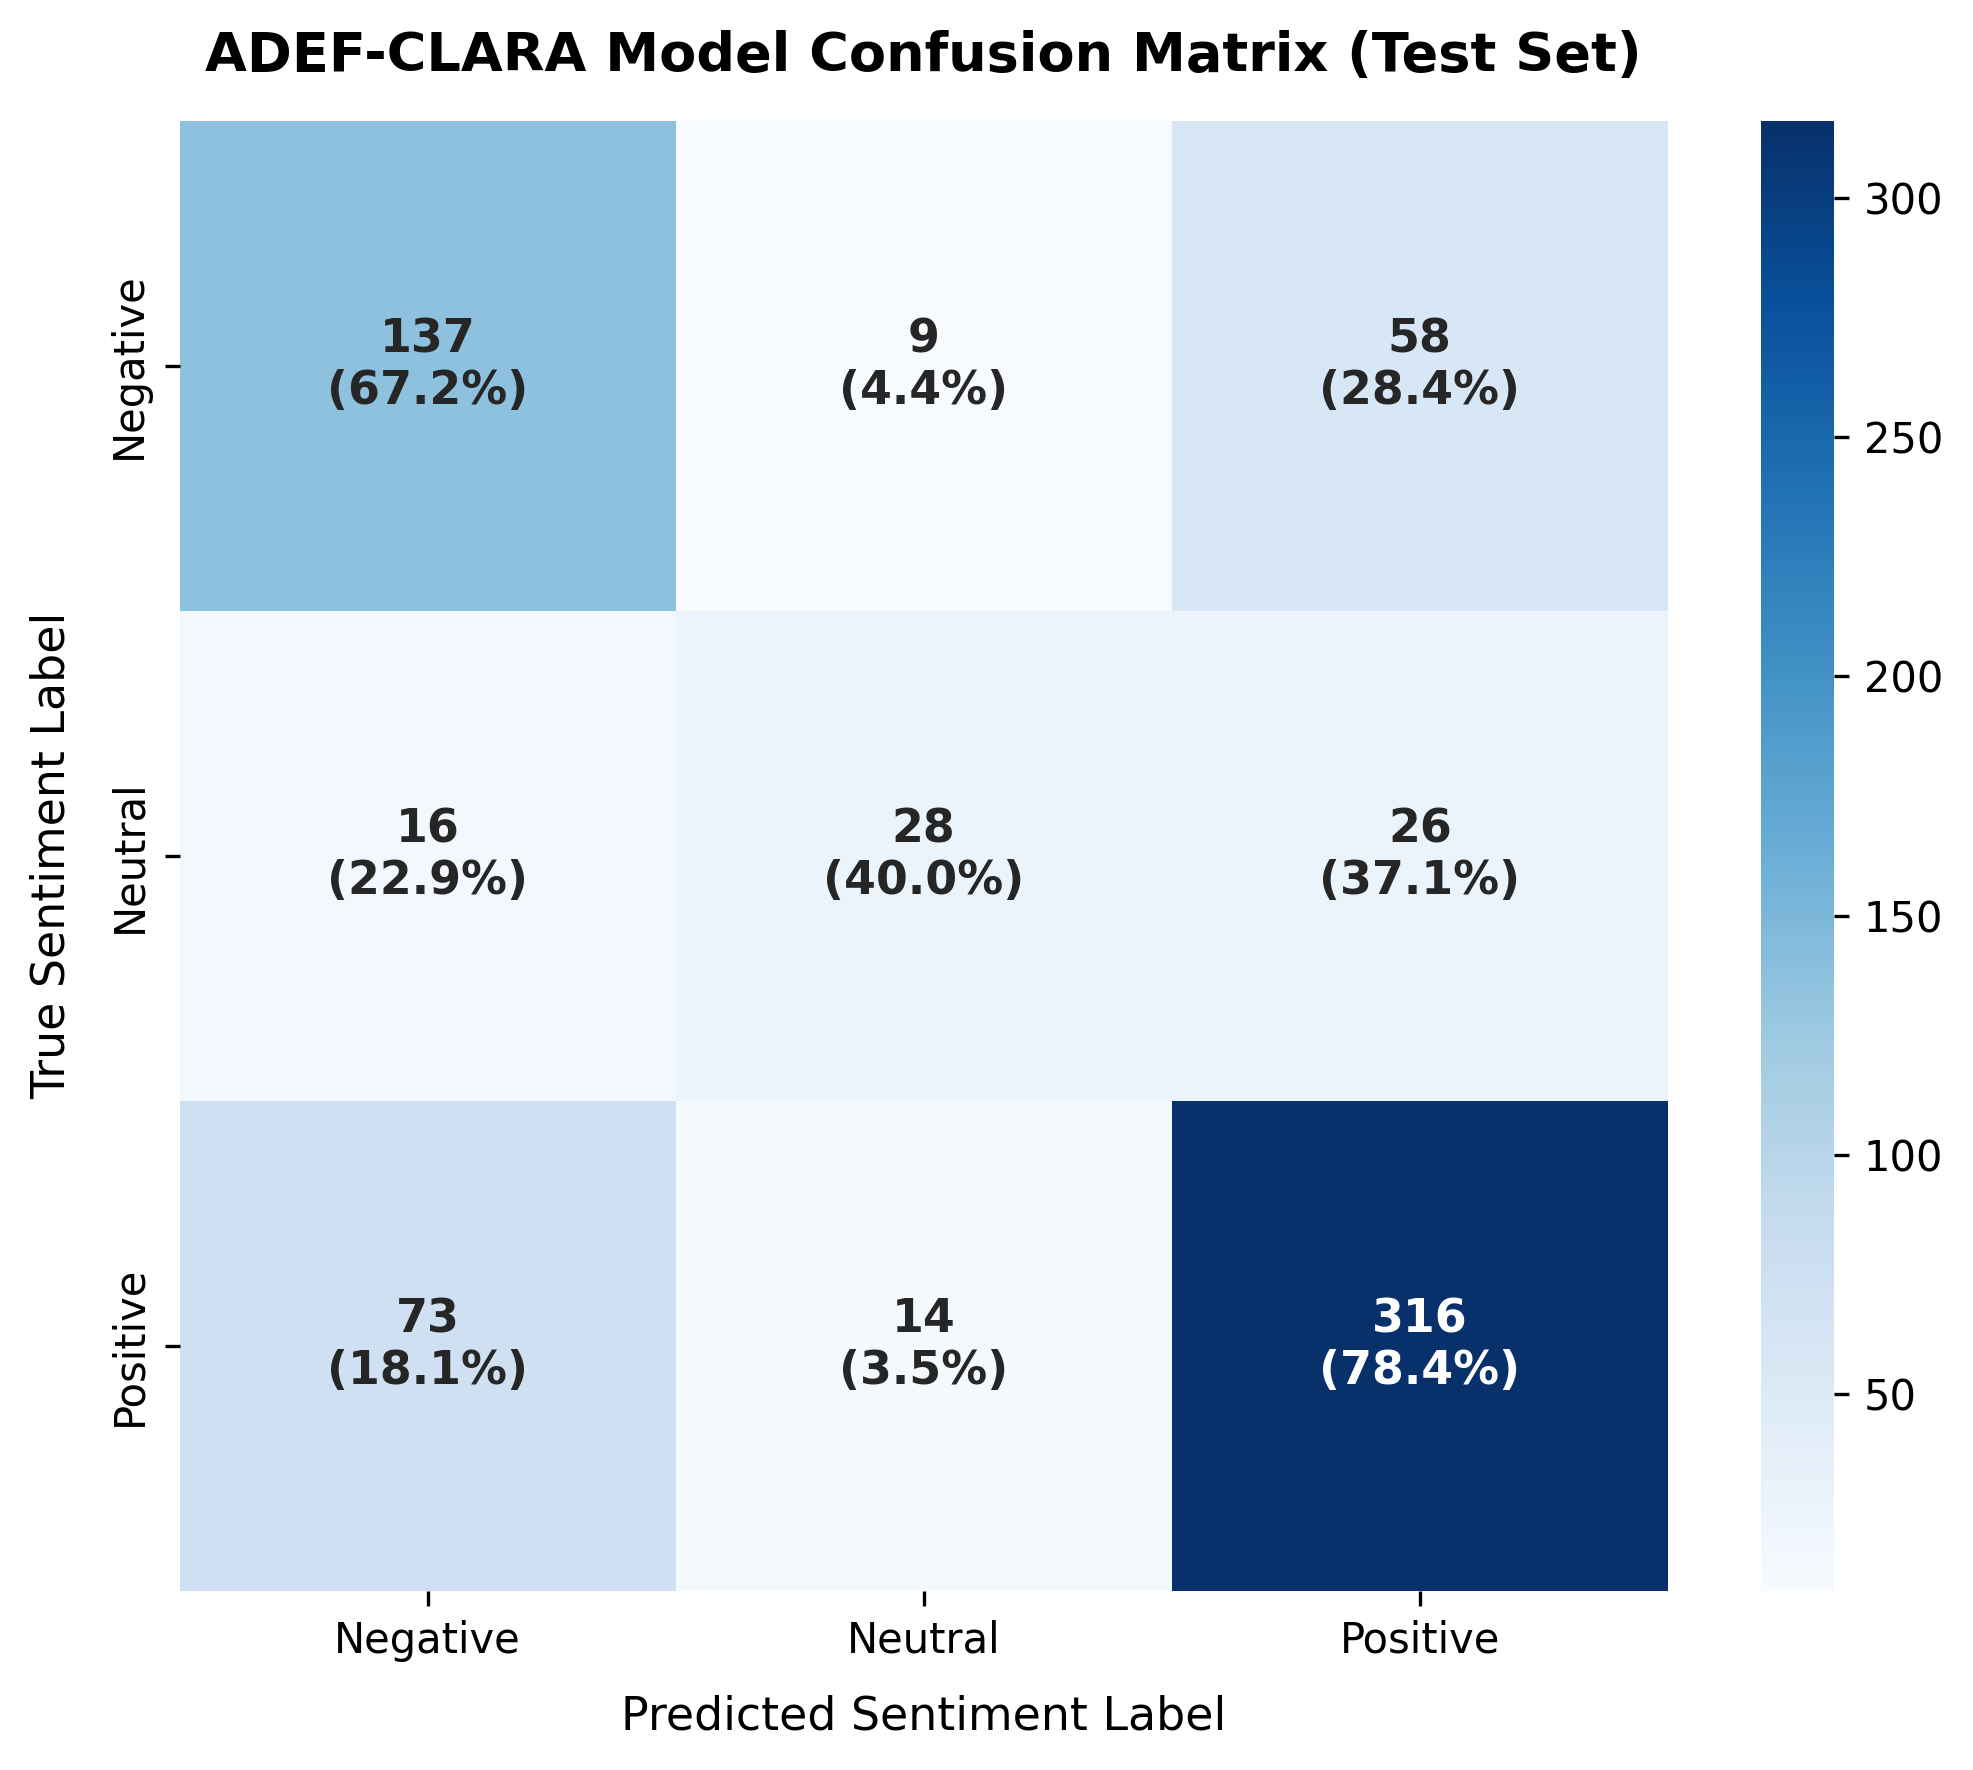

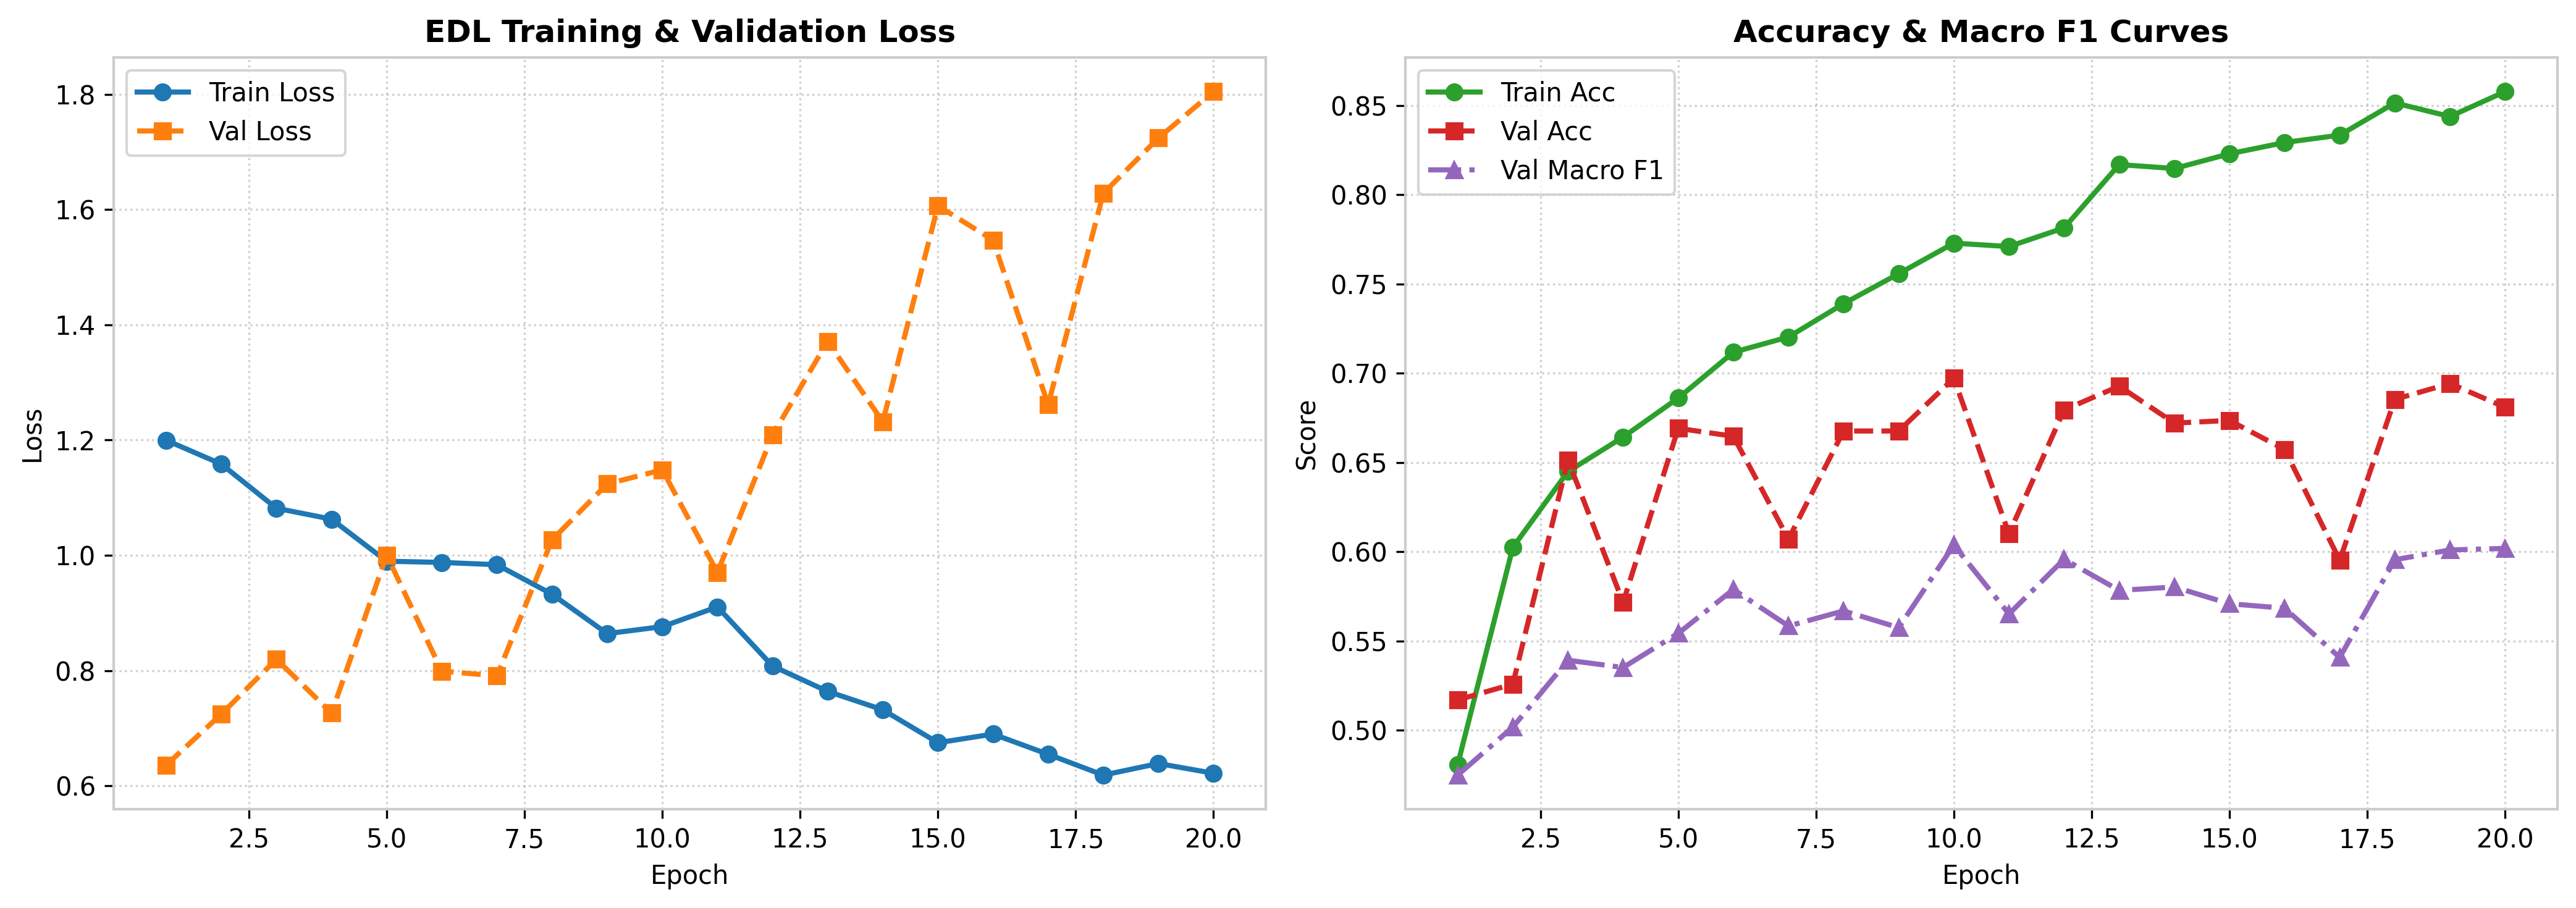

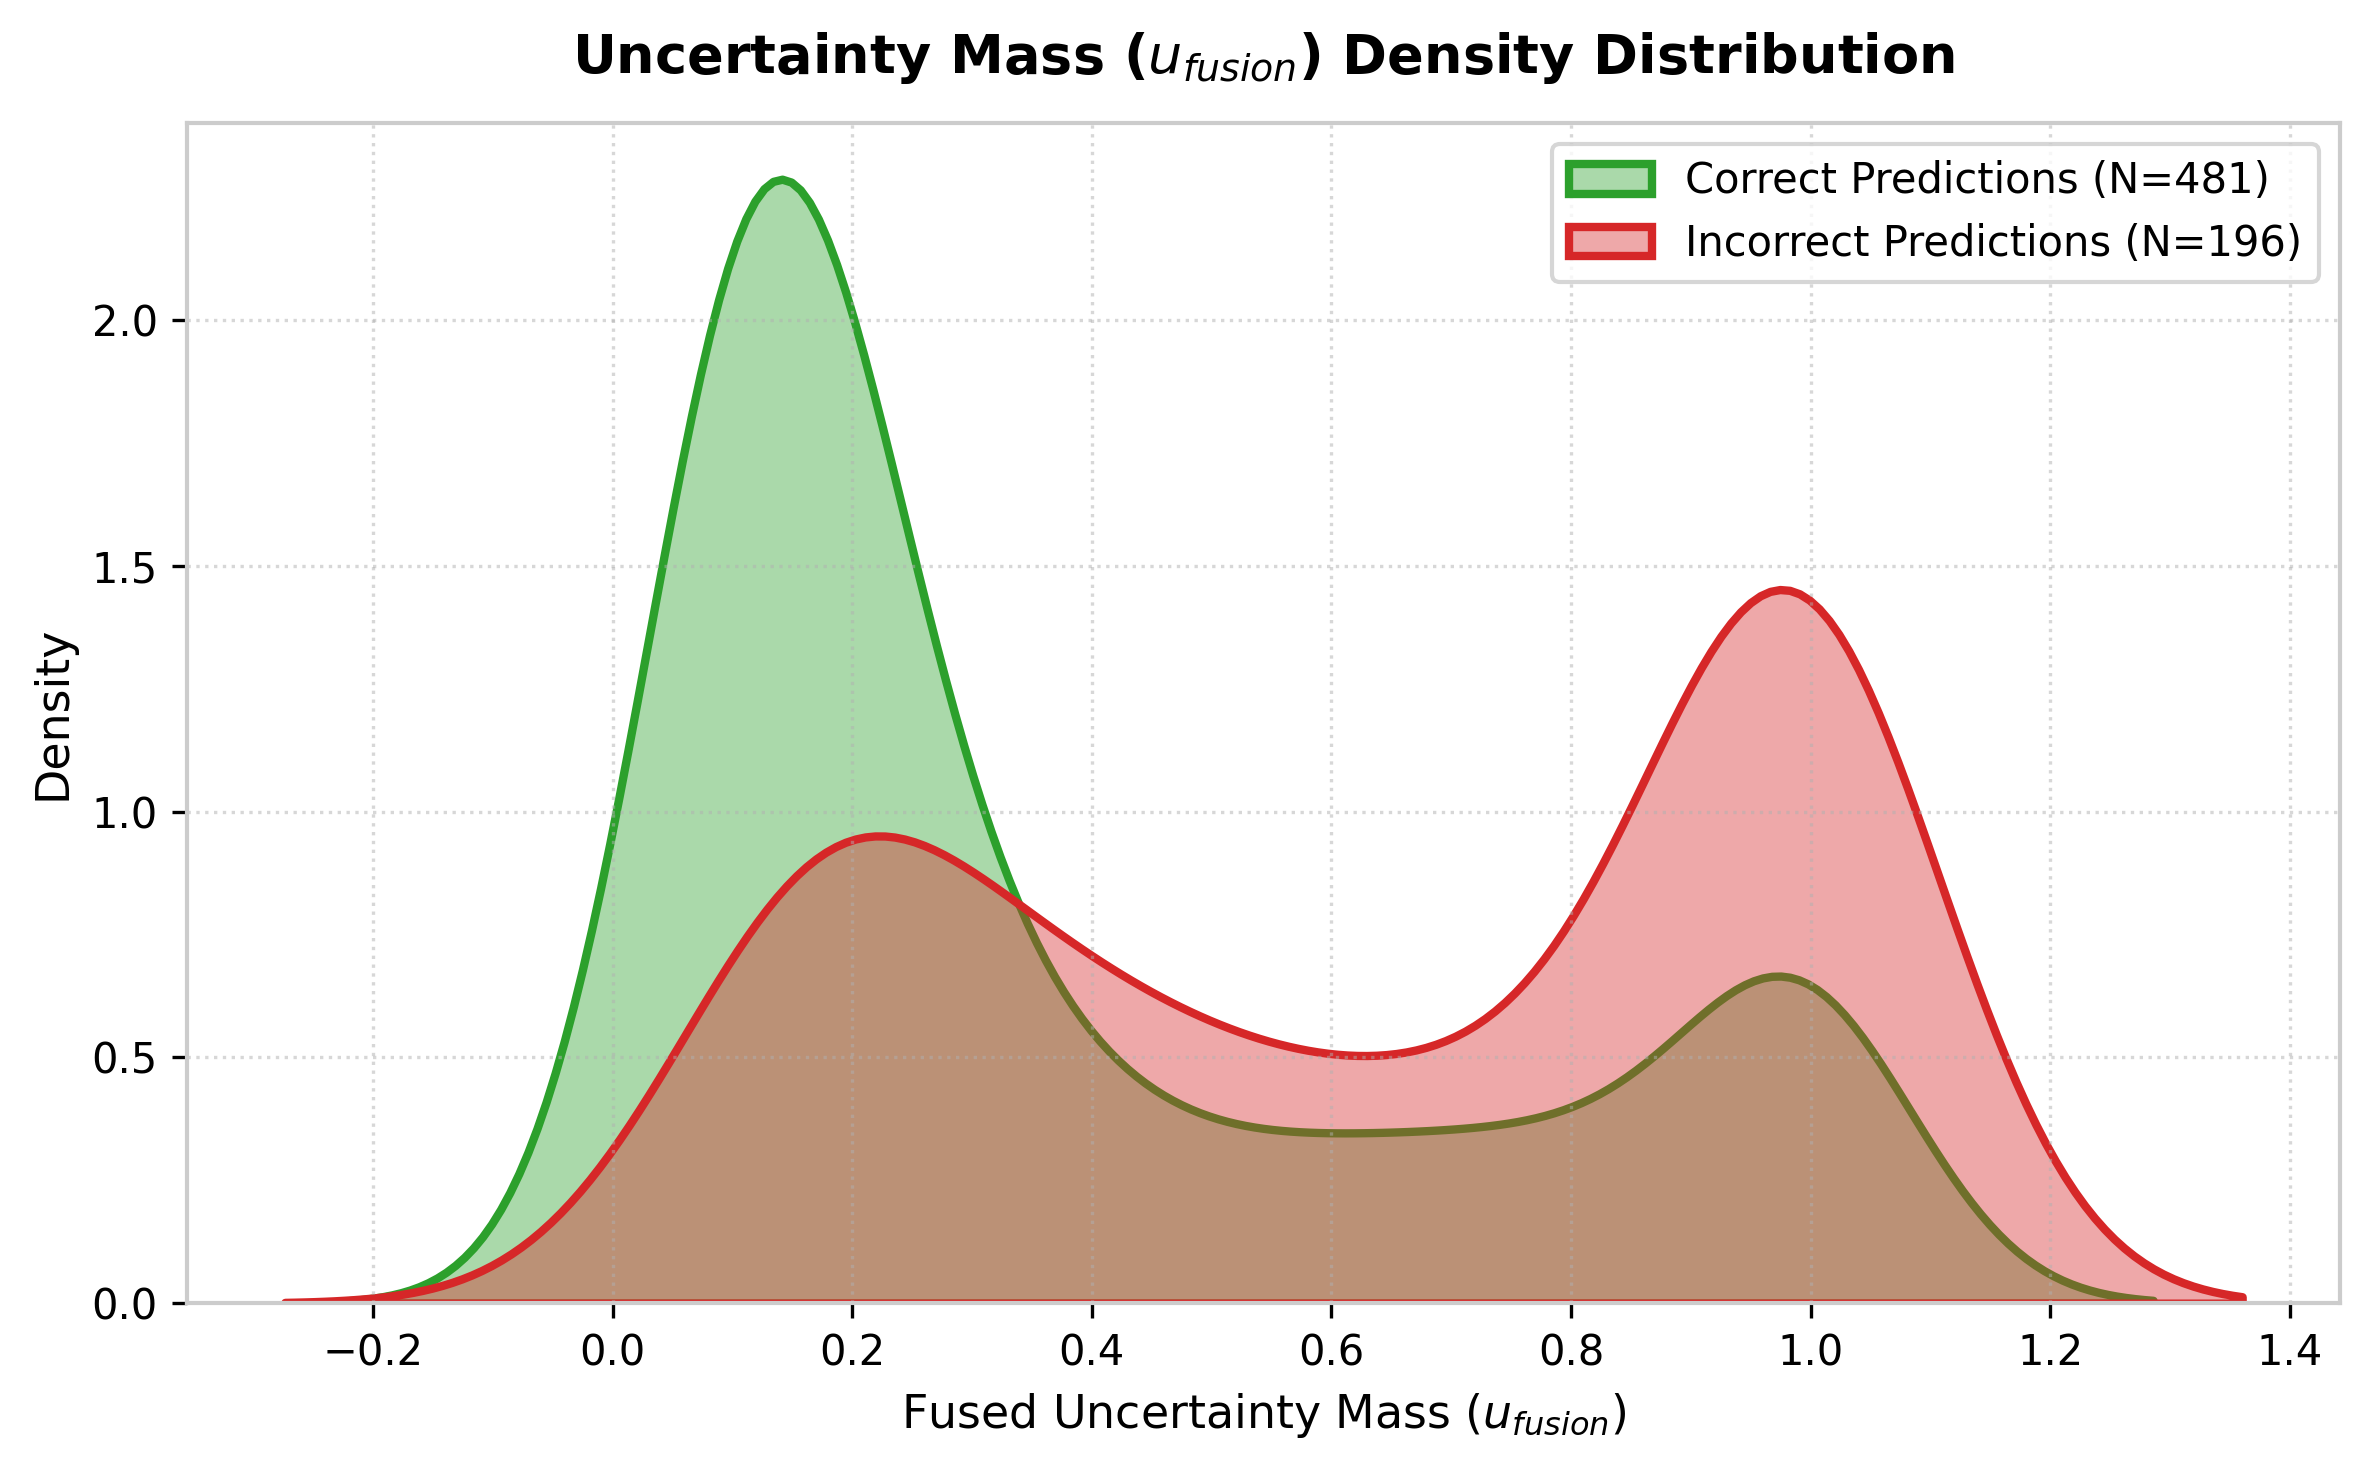

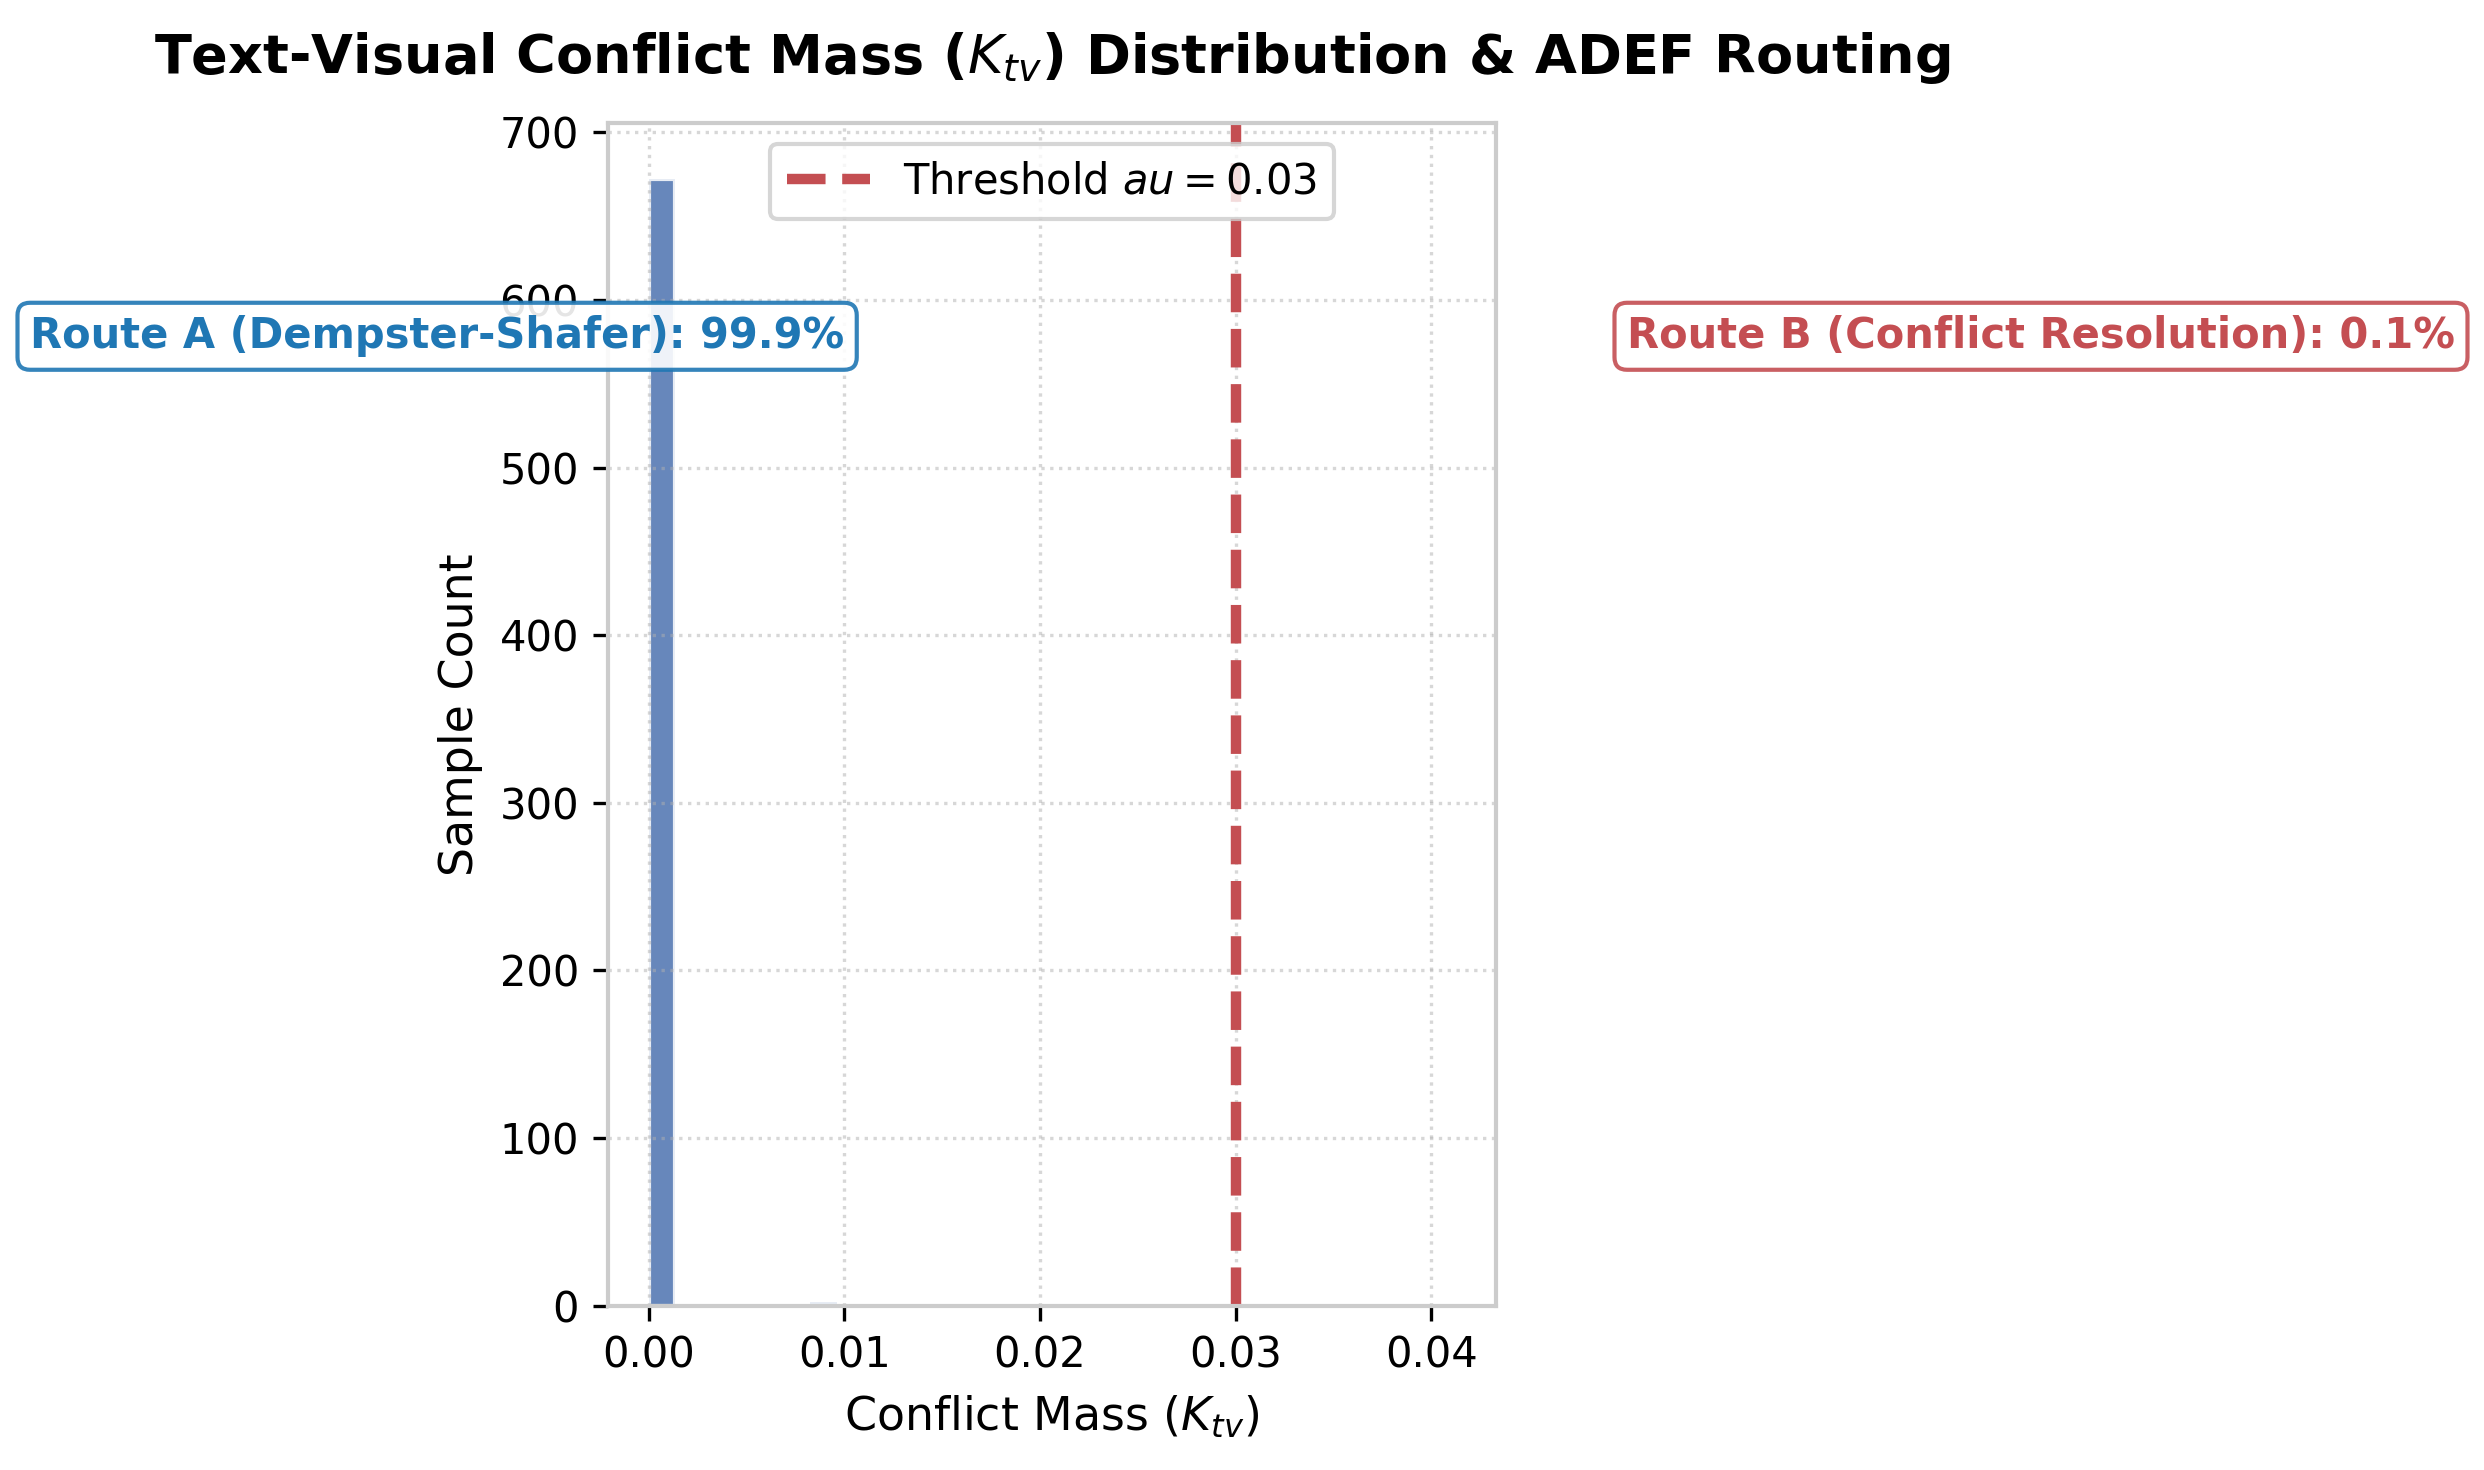

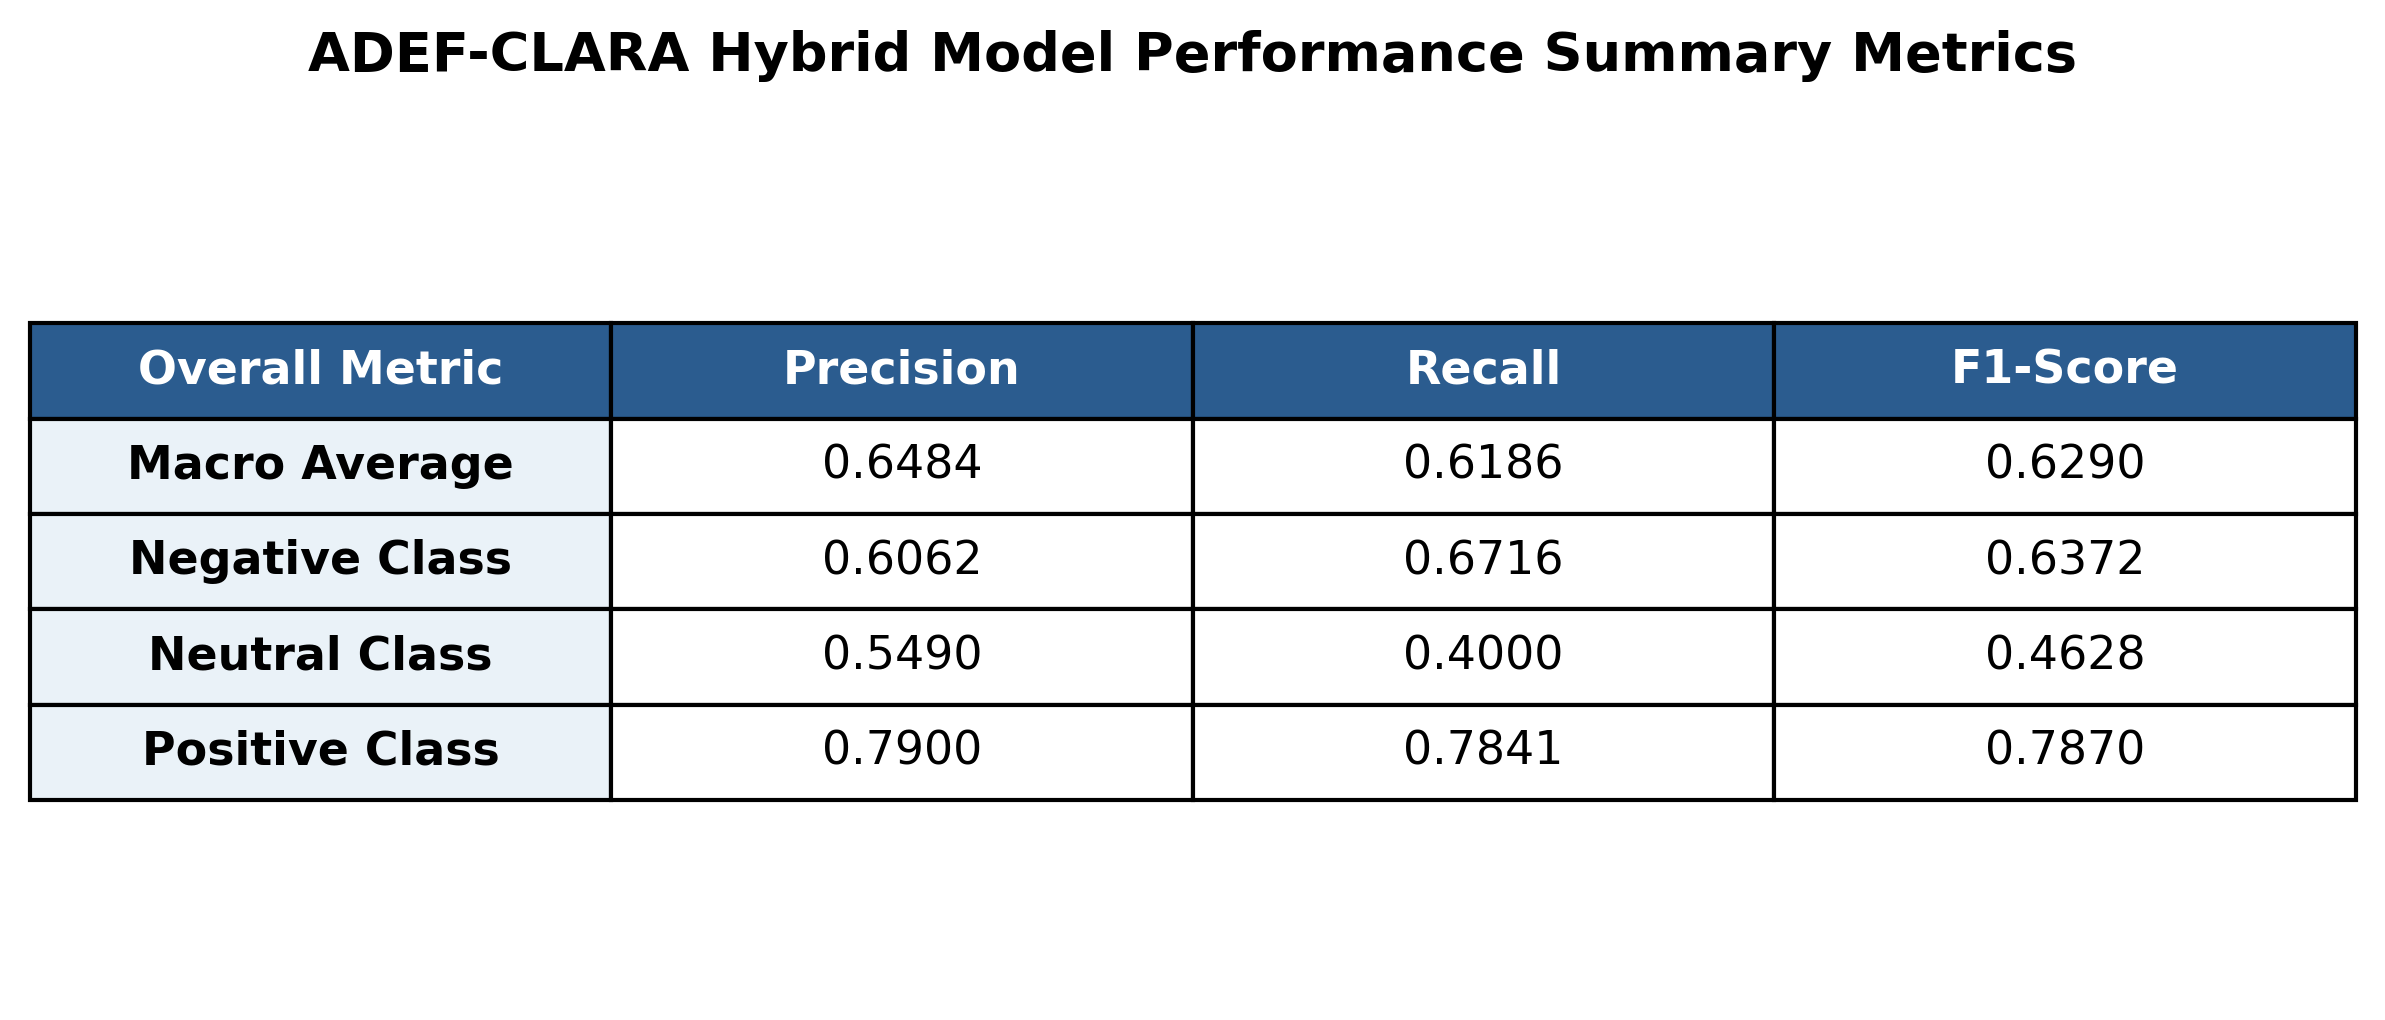

[INFO] All 5 publication-grade visualization plots rendered & saved to output_clara.


In [9]:
# ============================================================
# PUBLICATION-GRADE VISUALIZATIONS (300 DPI)
# ============================================================

plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 1.0

# ------------------------------------------------------------
# 1. Confusion Matrix Diagram
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = [f"{v}\n({p:.1%})" for v, p in zip(cm.flatten(), cm_norm.flatten())]
labels = np.asarray(labels).reshape(3, 3)

sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=True, ax=ax,
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 11, "weight": "bold"})
ax.set_title("ADEF-CLARA Model Confusion Matrix (Test Set)", fontsize=13, pad=12, weight="bold")
ax.set_xlabel("Predicted Sentiment Label", fontsize=11, labelpad=8)
ax.set_ylabel("True Sentiment Label", fontsize=11, labelpad=8)
plt.tight_layout()
if CFG.SAVE_PLOTS:
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"confusion_matrix.{CFG.PLOT_FORMAT}"), dpi=300)
plt.show()

# ------------------------------------------------------------
# 2. Training Dynamics & Performance Curves
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

epochs_range = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_range, history["train_loss"], "o-", color="#1f77b4", label="Train Loss", linewidth=2)
ax1.plot(epochs_range, history["val_loss"], "s--", color="#ff7f0e", label="Val Loss", linewidth=2)
ax1.set_title("EDL Training & Validation Loss", fontsize=12, weight="bold")
ax1.set_xlabel("Epoch", fontsize=10)
ax1.set_ylabel("Loss", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(frameon=True)

ax2.plot(epochs_range, history["train_acc"], "o-", color="#2ca02c", label="Train Acc", linewidth=2)
ax2.plot(epochs_range, history["val_acc"], "s--", color="#d62728", label="Val Acc", linewidth=2)
ax2.plot(epochs_range, history["val_f1"], "^-.", color="#9467bd", label="Val Macro F1", linewidth=2)
ax2.set_title("Accuracy & Macro F1 Curves", fontsize=12, weight="bold")
ax2.set_xlabel("Epoch", fontsize=10)
ax2.set_ylabel("Score", fontsize=10)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(frameon=True)

plt.tight_layout()
if CFG.SAVE_PLOTS:
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"training_dynamics.{CFG.PLOT_FORMAT}"), dpi=300)
plt.show()

# ------------------------------------------------------------
# 3. Uncertainty Mass (u_fusion) Distribution Plot
# ------------------------------------------------------------
correct_mask = (test_preds == test_labels)
u_correct = test_u_fusion[correct_mask]
u_incorrect = test_u_fusion[~correct_mask]

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
sns.kdeplot(u_correct, label=f"Correct Predictions (N={len(u_correct)})", fill=True, color="#2ca02c", alpha=0.4, linewidth=2, ax=ax)
sns.kdeplot(u_incorrect, label=f"Incorrect Predictions (N={len(u_incorrect)})", fill=True, color="#d62728", alpha=0.4, linewidth=2, ax=ax)
ax.set_title("Uncertainty Mass ($u_{fusion}$) Density Distribution", fontsize=13, pad=12, weight="bold")
ax.set_xlabel("Fused Uncertainty Mass ($u_{fusion}$)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(frameon=True)
plt.tight_layout()
if CFG.SAVE_PLOTS:
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"uncertainty_distribution.{CFG.PLOT_FORMAT}"), dpi=300)
plt.show()

# ------------------------------------------------------------
# 4. Conflict Mass (K_tv) Analysis & Routing Distribution
# ------------------------------------------------------------
route_a_pct = (test_K_tv <= CFG.TAU_THRESHOLD).mean() * 100
route_b_pct = (test_K_tv > CFG.TAU_THRESHOLD).mean() * 100

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
n, bins, patches = ax.hist(test_K_tv, bins=30, color="#4c72b0", edgecolor="white", alpha=0.85)
ax.axvline(CFG.TAU_THRESHOLD, color="#c44e52", linestyle="--", linewidth=2.5,
           label=f"Threshold $\tau = {CFG.TAU_THRESHOLD}$")

ax.text(CFG.TAU_THRESHOLD - 0.02, max(n)*0.85, f"Route A (Dempster-Shafer): {route_a_pct:.1f}%",
        horizontalalignment="right", fontsize=10, weight="bold", color="#1f77b4",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#1f77b4", alpha=0.9))

ax.text(CFG.TAU_THRESHOLD + 0.02, max(n)*0.85, f"Route B (Conflict Resolution): {route_b_pct:.1f}%",
        horizontalalignment="left", fontsize=10, weight="bold", color="#c44e52",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#c44e52", alpha=0.9))

ax.set_title("Text-Visual Conflict Mass ($K_{tv}$) Distribution & ADEF Routing", fontsize=13, pad=12, weight="bold")
ax.set_xlabel("Conflict Mass ($K_{tv}$)", fontsize=11)
ax.set_ylabel("Sample Count", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(frameon=True, loc="upper center")
plt.tight_layout()
if CFG.SAVE_PLOTS:
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"conflict_routing_distribution.{CFG.PLOT_FORMAT}"), dpi=300)
plt.show()

# ------------------------------------------------------------
# 5. Comprehensive Metrics Summary Table Plot
# ------------------------------------------------------------
precisions = precision_score(test_labels, test_preds, average=None)
recalls = recall_score(test_labels, test_preds, average=None)
f1s = f1_score(test_labels, test_preds, average=None)

table_data = [
    ["Overall Metric", "Precision", "Recall", "F1-Score"],
    ["Macro Average", f"{test_precision_macro:.4f}", f"{test_recall_macro:.4f}", f"{test_f1_macro:.4f}"],
    ["Negative Class", f"{precisions[0]:.4f}", f"{recalls[0]:.4f}", f"{f1s[0]:.4f}"],
    ["Neutral Class", f"{precisions[1]:.4f}", f"{recalls[1]:.4f}", f"{f1s[1]:.4f}"],
    ["Positive Class", f"{precisions[2]:.4f}", f"{recalls[2]:.4f}", f"{f1s[2]:.4f}"]
]

fig, ax = plt.subplots(figsize=(8, 3.5), dpi=300)
ax.axis("off")
table = ax.table(cellText=table_data, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for i in range(4):
    cell = table[(0, i)]
    cell.set_facecolor("#2b5c8f")
    cell.get_text().set_color("white")
    cell.get_text().set_weight("bold")

for j in range(1, 5):
    cell = table[(j, 0)]
    cell.set_facecolor("#eaf2f8")
    cell.get_text().set_weight("bold")

ax.set_title("ADEF-CLARA Hybrid Model Performance Summary Metrics", fontsize=13, pad=15, weight="bold")
plt.tight_layout()
if CFG.SAVE_PLOTS:
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"metrics_summary_table.{CFG.PLOT_FORMAT}"), dpi=300)
plt.show()

print("[INFO] All 5 publication-grade visualization plots rendered & saved to output_clara.")
